### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

15                Belarus
98              Lithuania
3                 Andorra
68                Grenada
61                 France
45         Czech Republic
141    Russian Federation
99             Luxembourg
155              Slovakia
81                Ireland
Name: country, dtype: str
media birre servite:106.16062176165804
media superalcolici serviti:80.99481865284974
media vini serviti:49.45077720207254
paese con maggiore alcohol index:Andorra
               country  beer_servings  spirit_servings  wine_servings  \
3              Andorra            245              138            312   
4               Angola            217               57             45   
5    Antigua & Barbuda            102              128             45   
6            Argentina            193               25            221   
8            Australia            261               72            212   
..                 ...            ...              ...            ...   
182     United Kingdom            219   

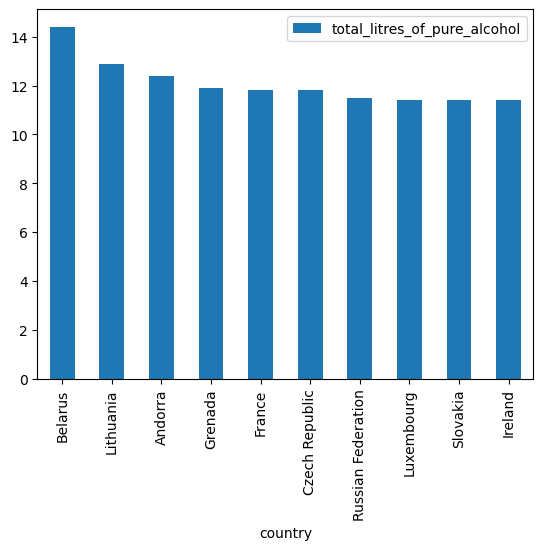

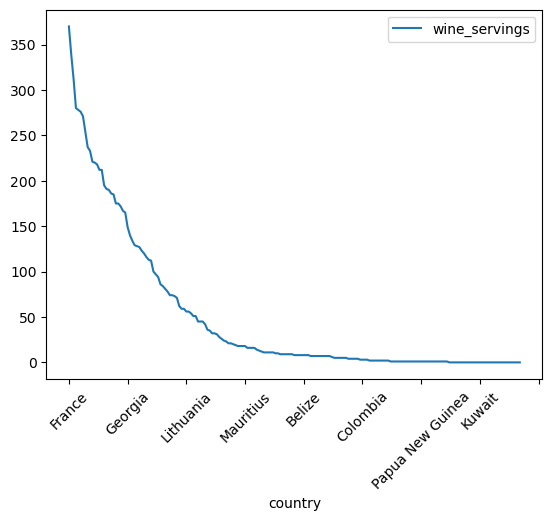

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")

# Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol(dal piu alto)
print((df
 .sort_values('total_litres_of_pure_alcohol',ascending=False)
 .head(10)
 .country))

#calcola la media del consumo di birra, vino, e distillati
print(f"media birre servite:{df.beer_servings.mean()}")
print(f"media superalcolici serviti:{df.spirit_servings.mean()}")
print(f"media vini serviti:{df.wine_servings.mean()}")

#Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`
df['alcohol_index']=((df.beer_servings+df.spirit_servings+df.wine_servings)/3).astype(float)

#Trova il paese con il valore massimo di alcohol_index
print(f"paese con maggiore alcohol index:{df.iloc[df.alcohol_index.argmax()].country}")

#Filtra solo i paesi che consumano più di 100 birre all’anno
print(df[df.beer_servings>100])

#Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)
(df
    .sort_values('total_litres_of_pure_alcohol',ascending=False)
    .head(10)
    .plot(x='country',y='total_litres_of_pure_alcohol',kind='bar')
    )

#Crea un line plot con wine_servings ordinato per paese (usa sort_values)
wine_sort=(df
 .sort_values('wine_servings',ascending=False)
 )

wine_sort.plot(x='country',y='wine_servings',kind='line')
plt.xticks(rotation=45)
plt.show()


### **2.Analisi offerte di lavoro** 
Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.


job_country
Afghanistan      16
Albania         119
Algeria         111
Angola           11
Argentina      8736
               ... 
Venezuela        69
Vietnam        2414
Yemen            10
Zambia          104
Zimbabwe         81
Length: 160, dtype: int64
             salary_min  salary_max  salary_range
job_country                                      
Albania         43200.0    157500.0      114300.0
Algeria         44100.0     45000.0         900.0
Argentina       45000.0    222000.0      177000.0
Armenia         45000.0    128682.0       83682.0
Australia       20000.0    257500.0      237500.0
...                 ...         ...           ...
Uruguay         50000.0    100500.0       50500.0
Uzbekistan      30750.0     30750.0           0.0
Vietnam         28000.0    200000.0      172000.0
Zambia          90670.0     90670.0           0.0
Zimbabwe        47500.0     90670.0       43170.0

[108 rows x 3 columns]


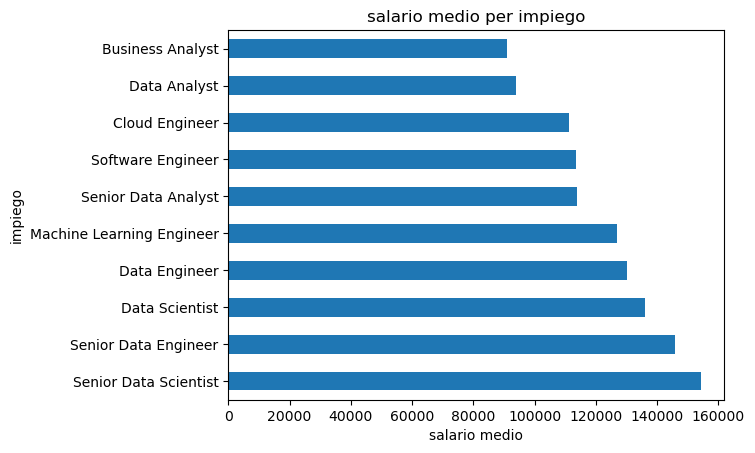

In [112]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

#per ogni paese:
#Lo **stipendio medio annuale** (`salary_year_avg`)
(df[df['salary_year_avg'].notna()]
 .groupby('job_country')['salary_year_avg']
 .mean()
)

#Il **numero totale di offerte di lavoro** (job count)
print(df.groupby('job_country').size())
 
#* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)
df_salary=(df[df['salary_year_avg'].notna()]
 .groupby('job_country').agg(
     salary_min=('salary_year_avg','min'),
     salary_max=('salary_year_avg','max')
 ))

df_salary['salary_range']=(df_salary['salary_max']-df_salary['salary_min'])
print(df_salary)


#Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.
(df[df['salary_year_avg'].notna()]
 .groupby('job_title_short')['salary_year_avg']
 .mean()
 .sort_values(ascending=False)
 .plot(kind='barh')
)
plt.title('salario medio per impiego')
plt.xlabel('salario medio')
plt.ylabel('impiego')
plt.show()

#

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
      media_conto  numero_ordinazioni  conto_minimo  conto_massimo
day                                                               
Fri     17.151579                  19          5.75          40.17
Sat     20.441379                  87          3.07          50.81
Sun     21.410000                  76          7.25          48.17
Thur    17.682742                  62          7.51          43.11


giorno conconto medio piu alto:Sun


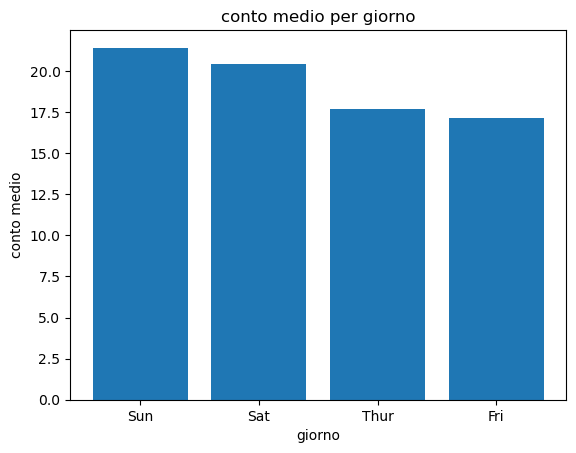

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

#per ogni giorno:
#Il **conto medio** (`total_bill`)
#Il **numero totale di osservazioni** (conteggio delle righe)
#Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)
df_stats=df.groupby('day').agg(
    media_conto=('total_bill','mean'),
    numero_ordinazioni=('day','count'),
    conto_minimo=('total_bill','min'),
    conto_massimo=('total_bill','max')
)
print(df_stats)

#Crea una nuova colonna `conto_per_persona` che sia:  
#  `total_bill / size`
df['conto_per_persona']=(df['total_bill']/df['size'])

#Trova il giorno con il **conto medio più alto**
print(f"giorno conconto medio piu alto:{df_stats.media_conto.idxmax()}")

#Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
#Ordina i dati dal valore più alto al più basso.  
#Aggiungi titolo ed etichette agli assi.
df_stats.sort_values('media_conto',ascending=False,inplace=True)
plt.bar(df_stats.index,df_stats['media_conto'])
plt.title('conto medio per giorno')
plt.xlabel('giorno')
plt.ylabel('conto medio')
plt.show()